## Install libraries





In [1]:
!pip install -qU langgraph langchain-groq pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.


In [2]:
import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("your_groq_api_key")

your_groq_api_key··········


In [3]:
from google.colab import files

In [4]:
import pandas as pd
uploaded=files.upload()

Saving doctors.csv to doctors.csv


In [5]:
doctors_df=pd.read_csv("doctors.csv")
doctors_df

,doctor_name,ward,status
0,Dr.mehta,General,busy
1,Dr.kapoor,General,busy
2,Dr.rao,emergency,free
3,Dr.singh,emergency,busy
4,Dr.iyer,mental_health,free
5,Dr.sharma,mental_health,busy


In [6]:
from typing import TypedDict,Literal

class Patientstate(TypedDict):
  name:str
  age:str
  query:str
  ward:str
  reasoning:str
  assigned_doctor:str

In [7]:
#create intake node
def intake_node(state: Patientstate) -> Patientstate:
  name=input("enter name:")
  age=input("enter age")
  query=input("description/symptoms if feeling anything wrong:")
  return {
      "name":name,
      "age":age,
      "query":query,
      "ward":"",
      "reasoning":"",
      "assigned_doctor":""
  }

In [8]:
from langchain_groq import ChatGroq

from langchain_core.messages import SystemMessage, HumanMessage



llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)



ROUTER_SYSTEM_PROMPT = """You are a hospital triage router. Based on the patient's

description, classify them into EXACTLY ONE of these wards:



- emergency: life-threatening or urgent physical conditions (severe pain, bleeding,

  breathing difficulty, chest pain, accidents, high fever, unconsciousness, etc.)

- mental_health: psychological/emotional distress (anxiety, depression, panic attacks,

  suicidal thoughts, self-harm, trauma, etc.)

- general: everything else (routine checkups, mild/chronic non-urgent symptoms, colds,

  minor aches, follow-ups, etc.)



Respond with ONLY one word: emergency, mental_health, or general.

"""
# Hard safety-net keywords — these always override the LLM, since misrouting

# a genuine crisis is unacceptable. Good example of "guardrail before AI".

EMERGENCY_KEYWORDS = ["chest pain", "can't breathe", "unconscious", "severe bleeding", "heart attack"]

CRISIS_KEYWORDS = ["suicide", "kill myself", "self-harm", "want to die"]

In [9]:
def router_node(state: Patientstate) -> Patientstate:

    query_lower = state["query"].lower()




    if any(kw in query_lower for kw in CRISIS_KEYWORDS):

        ward, reasoning = "mental_health", "Crisis keyword detected — routed immediately for safety."

    elif any(kw in query_lower for kw in EMERGENCY_KEYWORDS):

        ward, reasoning = "emergency", "Emergency keyword detected — routed immediately for safety."

    else:

        response = llm.invoke([

            SystemMessage(content=ROUTER_SYSTEM_PROMPT),

            HumanMessage(content=f"Age: {state['age']}\nSymptoms: {state['query']}")

        ])

        raw = response.content.strip().lower()
        # Defensive parsing in case the model adds extra words

        if "emergency" in raw:

            ward = "emergency"

        elif "mental_health" in raw or "mental health" in raw:

            ward = "mental_health"

        elif "general" in raw:

            ward = "general"

        else:

            ward = "general"  # safe default



        reasoning = f"LLM classified based on: '{state['query']}'"



    return {**state, "ward": ward, "reasoning": reasoning}

In [10]:
def general_ward_node(state:Patientstate) -> Patientstate:

    print(f"\n{state['name']} -> GENERAL WARD")

    print(f"Reason: {state['reasoning']}")

    return state





def emergency_ward_node(state:Patientstate) -> Patientstate:

    print(f"\n{state['name']} -> EMERGENCY WARD (priority)")

    print(f"Reason: {state['reasoning']}")

    return state





def mental_health_ward_node(state:Patientstate) -> Patientstate:

    print(f"\n{state['name']} -> MENTAL HEALTH WARD")

    print(f"Reason: {state['reasoning']}")

    return state

In [11]:
def doctor_availability_node(state: Patientstate) -> Patientstate:

    ward = state["ward"]



    available = doctors_df[

        (doctors_df["ward"] == ward) & (doctors_df["status"] == "free")

    ]



    if not available.empty:

        doctor = available.iloc[0]["doctor_name"]

        assigned_doctor = doctor

        # Mark doctor busy for the rest of this Colab session

        doctors_df.loc[doctors_df["doctor_name"] == doctor, "status"] = "busy"

    else:

        assigned_doctor = "No doctor currently free — patient will be queued"



    print(f"👨‍⚕️ Doctor assigned: {assigned_doctor}")

    return {**state, "assigned_doctor": assigned_doctor}

In [12]:
from langgraph.graph import StateGraph, END



def route_decision(state: Patientstate) -> Literal["general", "emergency", "mental_health"]:

    return state["ward"]



builder = StateGraph(Patientstate)



builder.add_node("intake", intake_node)

builder.add_node("router", router_node)

builder.add_node("general", general_ward_node)

builder.add_node("emergency", emergency_ward_node)

builder.add_node("mental_health", mental_health_ward_node)

builder.add_node("doctor_check", doctor_availability_node)



builder.set_entry_point("intake")

builder.add_edge("intake", "router")



builder.add_conditional_edges(

    "router",

    route_decision,

    {

        "general": "general",

        "emergency": "emergency",

        "mental_health": "mental_health",

    },

)



builder.add_edge("general", "doctor_check")

builder.add_edge("emergency", "doctor_check")

builder.add_edge("mental_health", "doctor_check")



builder.add_edge("doctor_check", END)



graph = builder.compile()

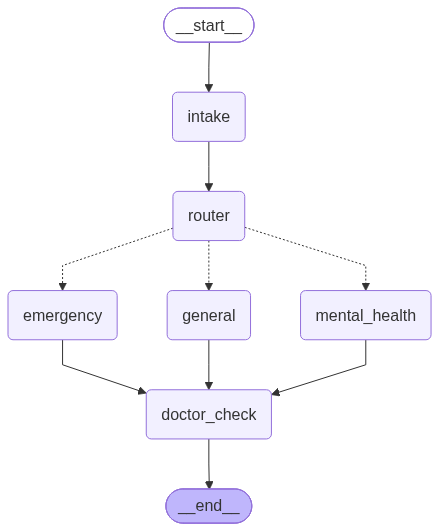

In [13]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
final_state = graph.invoke({})

print("\n=== Final Summary ===")

print(f"Patient: {final_state['name']} (Age: {final_state['age']})")

print(f"Ward: {final_state['ward']}")

print(f"Assigned Doctor: {final_state['assigned_doctor']}")

enter name:himanshu
enter age29
description/symptoms if feeling anything wrong:i am depressed

himanshu -> MENTAL HEALTH WARD
Reason: LLM classified based on: 'i am depressed'
👨‍⚕️ Doctor assigned: No doctor currently free — patient will be queued

=== Final Summary ===
Patient: himanshu (Age: 29)
Ward: mental_health
Assigned Doctor: No doctor currently free — patient will be queued


In [15]:
doctors_df

,doctor_name,ward,status
0,Dr.mehta,General,busy
1,Dr.kapoor,General,busy
2,Dr.rao,emergency,free
3,Dr.singh,emergency,busy
4,Dr.iyer,mental_health,busy
5,Dr.sharma,mental_health,busy
